Part 1 — Q1.1: Array Creation & Statistical Filtering

In [1]:
import numpy as np
array_1d = np.linspace(0, 20, 100)
print("Array (first 10 values shown):", array_1d[:10])
print("Total number of values:", len(array_1d))
mean   = np.mean(array_1d)
median = np.median(array_1d)
std    = np.std(array_1d)
var    = np.var(array_1d)
print("\n--- Statistical Measures ---")
print(f"Mean     : {mean:.4f}")
print(f"Median   : {median:.4f}")
print(f"Std Dev  : {std:.4f}")
print(f"Variance : {var:.4f}")

Array (first 10 values shown): [0.         0.2020202  0.4040404  0.60606061 0.80808081 1.01010101
 1.21212121 1.41414141 1.61616162 1.81818182]
Total number of values: 100

--- Statistical Measures ---
Mean     : 10.0000
Median   : 10.0000
Std Dev  : 5.8315
Variance : 34.0067


Part 1-Q1.2:- Reshaping

In [2]:
array_36 = np.arange(1, 37)   # arange(1, 37) gives 1 to 36


print("1D array:", array_36)


# Step 2: Reshape to 4 rows x 9 columns
matrix_4x9 = array_36.reshape(4, 9)

print("\nReshaped to (4x9):")
print(matrix_4x9)

# Step 3: Flatten back to 1D
flattened = matrix_4x9.flatten()

print("\nStep 3 — Flattened back to 1D:", flattened)


1D array: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]

Reshaped to (4x9):
[[ 1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18]
 [19 20 21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34 35 36]]

Step 3 — Flattened back to 1D: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]


Part 2 - Pandas & Data Wrangling


In [3]:
import pandas as pd       # for data manipulation
import seaborn as sns     # seaborn has the titanic dataset built-in
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df = sns.load_dataset('titanic')
print("=== First 5 Rows ===")
print(df.head()) #Display first 5 rows
print("\n=== Dataset Info ===")
df.info() #shows column names, data types, non-null counts
print("\n=== Statistical Summary ===")
print(df.describe()) #statistical summary of numerical columns



=== First 5 Rows ===
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ----------

Part 2- 2.2: Missing Value Treatment


In [4]:
print("\n=== Missing Values ===")
missing_count = df.isnull().sum()                         # count of nulls per column
missing_percent = (df.isnull().sum() / len(df)) * 100     # percentage missing
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)
df['age'] = df['age'].fillna(df.groupby('pclass')['age'].transform('median'))
print("\nMissing values in 'age' after filling:", df['age'].isnull().sum())
embarked_mode = df['embarked'].mode()[0]   # mode() returns a Series, [0] gets the value
df['embarked'] = df['embarked'].fillna(embarked_mode)
print("Missing values in 'embarked' after filling:", df['embarked'].isnull().sum())
df = df.drop(columns=['deck'])
print("'deck' column dropped.")
print("\n=== Null check after treatment ===")
print(df[['age', 'embarked']].isnull().sum())
print("\n=== All remaining nulls in dataset ===")
print(df.isnull().sum())


=== Missing Values ===
             Missing Count  Missing %
age                    177      19.87
embarked                 2       0.22
deck                   688      77.22
embark_town              2       0.22

Missing values in 'age' after filling: 0
Missing values in 'embarked' after filling: 0
'deck' column dropped.

=== Null check after treatment ===
age         0
embarked    0
dtype: int64

=== All remaining nulls in dataset ===
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


Part 3 — Matplotlib Visualizations
Q3.1 — Histogram







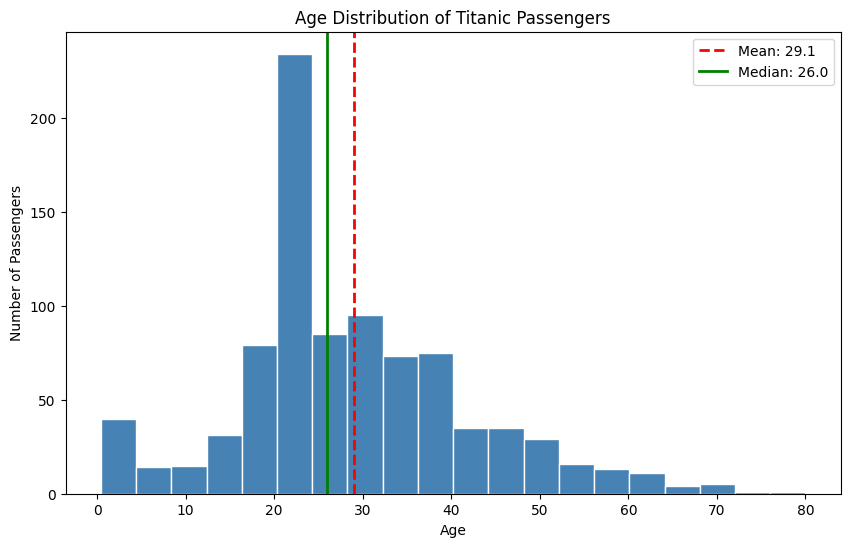

In [5]:

import matplotlib.pyplot as plt  # importing matplotlib for plotting


# Create a blank canvas of size 10x6 inches
plt.figure(figsize=(10, 6))

# Draw the histogram — 20 bins, steelblue color, white edges between bars
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')

# Calculate mean and median age
mean_age = df['age'].mean()
median_age = df['age'].median()

# Draw vertical dashed red line at mean age
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_age:.1f}')

# Draw vertical solid green line at median age
plt.axvline(median_age, color='green', linestyle='solid', linewidth=2, label=f'Median: {median_age:.1f}')

# Add title and axis labels
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

# Add legend to identify the two lines
plt.legend()

# Display the plot
plt.show()

The age distribution is slightly right-skewed — most passengers
were between 20-40 years old. The mean is slightly higher than
the median, which confirms the right skew (a few older passengers
are pulling the mean upward).

Q3.2 — Scatter Plot with Color Encoding


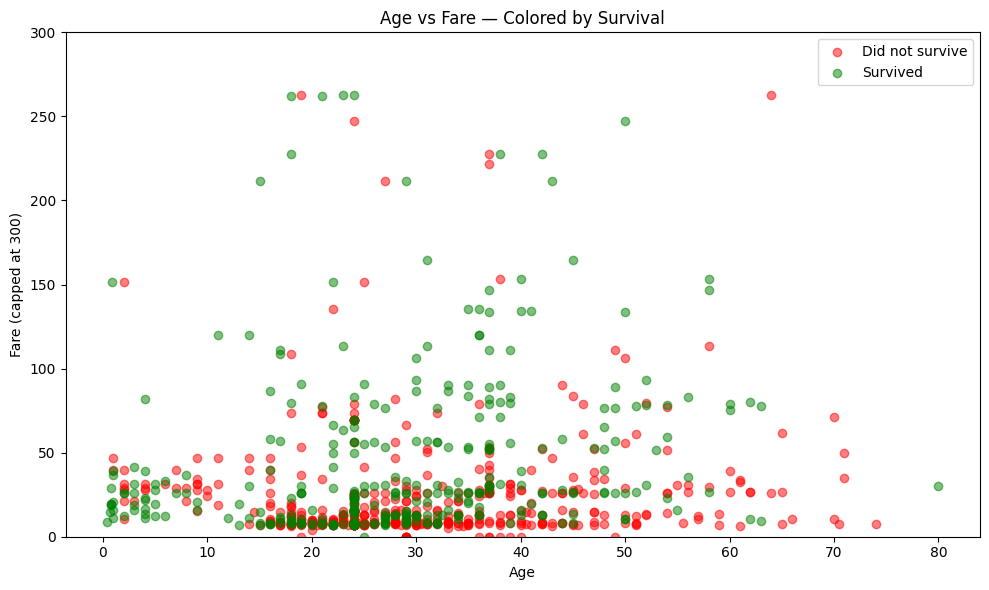

In [6]:

survived = df[df['survived'] == 1]   # passengers who survived
died     = df[df['survived'] == 0]   # passengers who did not survive

# Create blank canvas
plt.figure(figsize=(10, 6))

# Plot died passengers as red dots
plt.scatter(died['age'], died['fare'],
            color='red', alpha=0.5, label='Did not survive')

# Plot survived passengers as green dots
plt.scatter(survived['age'], survived['fare'],
            color='green', alpha=0.5, label='Survived')

# Cap y-axis at 300
plt.ylim(0, 300)

# Add title and axis labels
plt.title('Age vs Fare — Colored by Survival')
plt.xlabel('Age')
plt.ylabel('Fare (capped at 300)')

# Add legend to identify red and green dots
plt.legend()

# Adjust layout so nothing overlaps or gets cut off
plt.tight_layout()

# Display the plot
plt.show()

The y-axis has been capped at 300 to improve readability.
A small number of passengers paid fares above 300, which were
extreme outliers that would compress the majority of data points
into a narrow band at the bottom of the plot.

From the scatter plot, green dots (survived) appear slightly more
concentrated at higher fare values, suggesting that passengers who
paid more (likely 1st class) had a better chance of survival.
Age alone does not show a strong pattern.

Part 4 — Exploratory Data Analysis


Q4.1 — Initial Inspection


Shape: (200, 4)

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


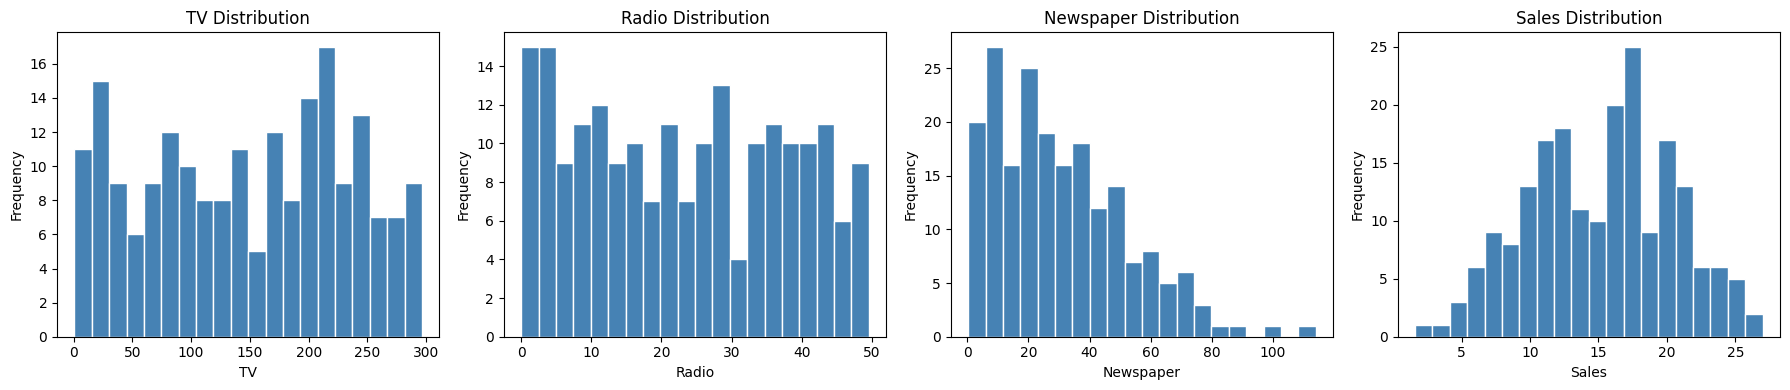

In [9]:


import pandas as pd
import matplotlib.pyplot as plt
# Load the advertising dataset from URL
df_ad = pd.read_csv('advertising.csv')
# Shape: how many rows and columns
print("Shape:", df_ad.shape)

# Data types of each column
print("\nData Types:")
print(df_ad.dtypes)

# Missing values per column
print("\nMissing Values:")
print(df_ad.isnull().sum())

# Step 2 — Statistical summary
print("\nStatistical Summary:")
print(df_ad.describe())

# Step 3 — Plot 4 histograms in a 1x4 subplot

# Create a figure with 1 row and 4 columns of subplots
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# List of columns to plot
columns = ['TV', 'Radio', 'Newspaper', 'Sales']

# Loop through each column and draw its histogram
for i, col in enumerate(columns):
    axes[i].hist(df_ad[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} Distribution')   # title for each subplot
    axes[i].set_xlabel(col)                    # x-axis label
    axes[i].set_ylabel('Frequency')            # y-axis label

# Adjust spacing and display
plt.tight_layout()
plt.show()

Q4.2 — Correlation Analysis


Correlation Matrix:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


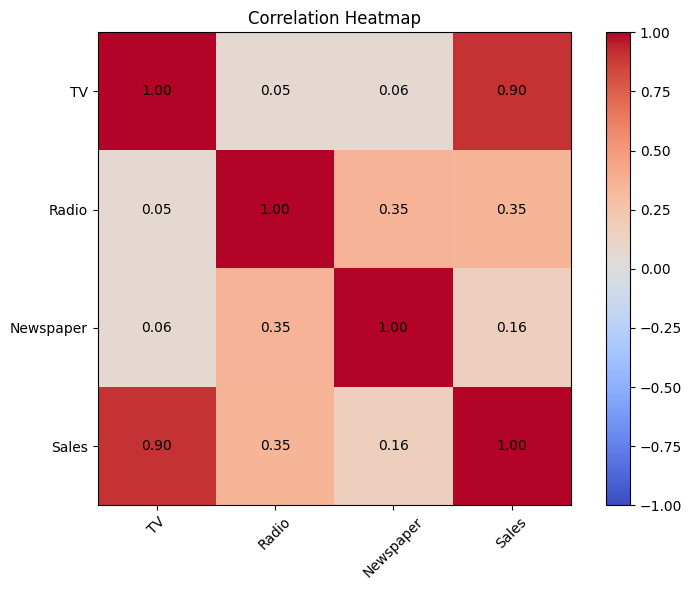

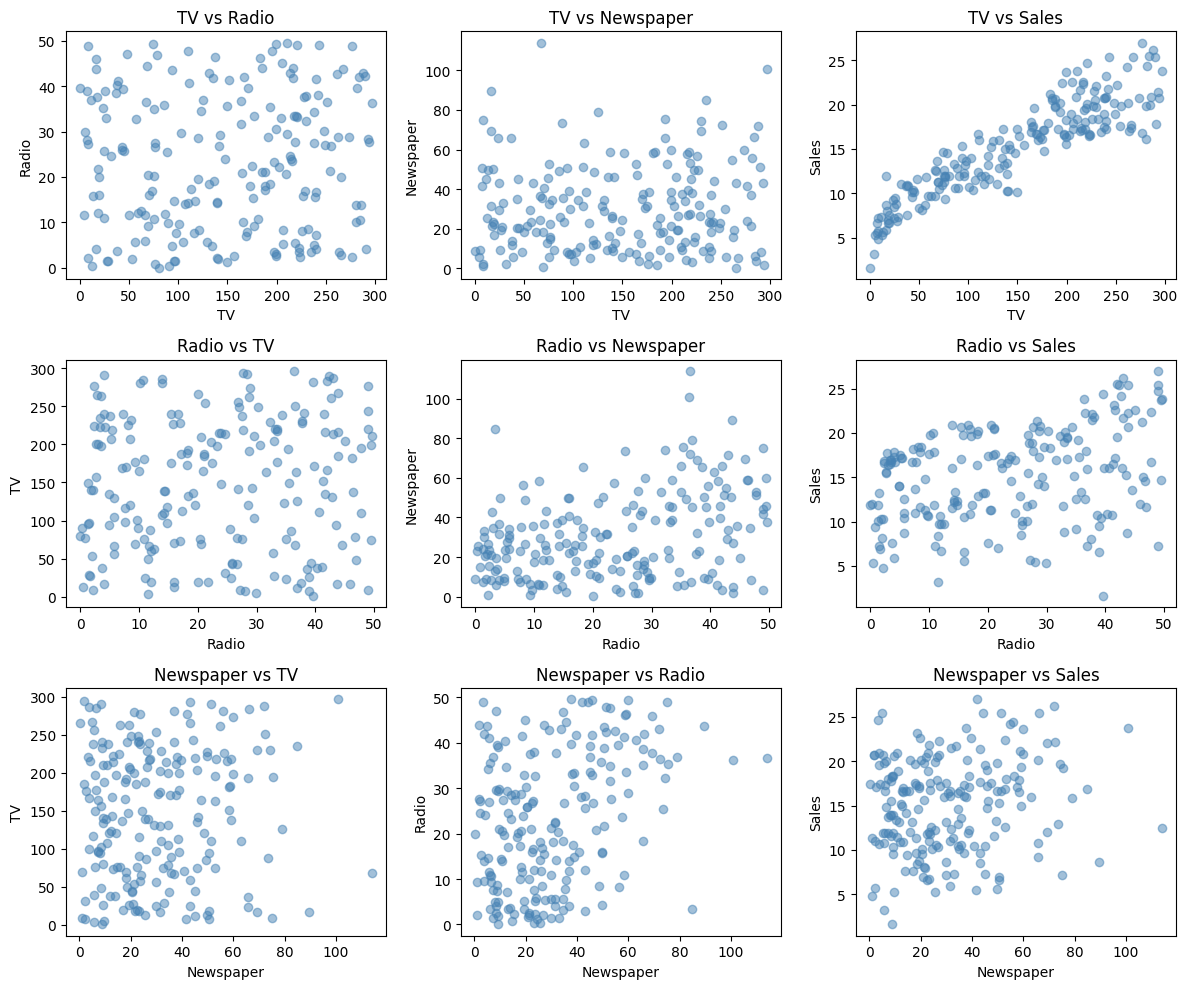

In [10]:
# Step 1 — Compute correlation matrix
corr_matrix = df_ad.corr()
print("Correlation Matrix:")
print(corr_matrix)

# Step 2 — Visualize as heatmap using imshow

plt.figure(figsize=(8, 6))

# Draw color-coded grid
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar on the side
plt.colorbar(im)

# Set axis labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Annotate each cell with the correlation value rounded to 2 decimals
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                 ha='center', va='center', color='black', fontsize=10)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Step 3 — 3x3 scatter plot grid of all variable pairs

columns = ['TV', 'Radio', 'Newspaper', 'Sales']

# Create 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

# Define all 9 pairs to plot
pairs = [
    ('TV', 'Radio'),      ('TV', 'Newspaper'),      ('TV', 'Sales'),
    ('Radio', 'TV'),      ('Radio', 'Newspaper'),    ('Radio', 'Sales'),
    ('Newspaper', 'TV'),  ('Newspaper', 'Radio'),    ('Newspaper', 'Sales')
]

# Loop through pairs and draw each scatter plot
for idx, (x_col, y_col) in enumerate(pairs):
    row = idx // 3    # row number in the grid
    col = idx % 3     # column number in the grid
    axes[row][col].scatter(df_ad[x_col], df_ad[y_col],
                           color='steelblue', alpha=0.5)
    axes[row][col].set_xlabel(x_col)
    axes[row][col].set_ylabel(y_col)
    axes[row][col].set_title(f'{x_col} vs {y_col}')

plt.tight_layout()
plt.show()

Correlation Analysis:

1. Most correlated with Sales:
   TV has the highest correlation with Sales (~0.78),
   meaning TV advertising spend is the strongest predictor
   of sales among the three channels.

2. TV vs Radio correlation:
   TV and Radio have a low correlation (~0.05),
   meaning they are largely independent of each other —
   companies that spend more on TV don't necessarily
   spend more or less on Radio.

3. From the scatter plots:
   TV vs Sales shows a clear upward trend (strong relationship).
   Newspaper vs Sales shows a weak, scattered pattern.
   Radio vs Sales shows a moderate positive relationship.

Part 5 — Linear Regression


Q5.1 — Scratch Implementation: Simple Linear Regression


In [11]:

import numpy as np
# Extract TV (input) and Sales (output) as NumPy arrays
X = df_ad['TV'].values
y = df_ad['Sales'].values

# Step 1 — Manually split: first 160 = train, rest = test
X_train, y_train = X[:160], y[:160]
X_test,  y_test  = X[160:], y[160:]

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Step 2 — Compute means of training data
x_mean = X_train.mean()   # mean of TV spend (x̄)
y_mean = y_train.mean()   # mean of Sales (ȳ)

# Step 3 — Compute slope (m) using closed-form formula
numerator   = np.sum((X_train - x_mean) * (y_train - y_mean))  # Σ(xi - x̄)(yi - ȳ)
denominator = np.sum((X_train - x_mean) ** 2)                   # Σ(xi - x̄)²
m = numerator / denominator

# Step 4 — Compute intercept (b)
b = y_mean - m * x_mean   # b = ȳ - m × x̄

# Step 5 — Print slope and intercept
print(f"\nSlope (m)     : {m:.4f}")
print(f"Intercept (b) : {b:.4f}")
print(f"\nLine equation : Sales = {m:.4f} × TV + {b:.4f}")

# Step 6 — Generate predictions on test set
y_pred = m * X_test + b   # apply y = mx + b to each test value

# Step 7 — Compute MSE manually
mse = np.mean((y_test - y_pred) ** 2)   # average of squared errors

print(f"\nMSE on test set: {mse:.4f}")

Training samples : 160
Test samples     : 40

Slope (m)     : 0.0557
Intercept (b) : 6.9937

Line equation : Sales = 0.0557 × TV + 6.9937

MSE on test set: 5.4598


Q5.2 — Sklearn Implementation

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Prepare X (input) and y (output)
# Double brackets for X — sklearn needs a 2D array
X = df_ad[['TV']]
y = df_ad['Sales']

# Step 1 — Split 80/20 randomly with fixed random state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Step 2 — Create and train the LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)   # model learns slope and intercept automatically

# Step 3 — Print sklearn slope and intercept
print(f"\nSklearn Slope (m)     : {model.coef_[0]:.4f}")
print(f"Sklearn Intercept (b) : {model.intercept_:.4f}")

# Compare with Q5.1 scratch values
print(f"\nQ5.1 Slope (m)        : {m:.4f}")
print(f"Q5.1 Intercept (b)    : {b:.4f}")

print(f"\nDifference in slope     : {abs(model.coef_[0] - m):.4f}")
print(f"Difference in intercept : {abs(model.intercept_ - b):.4f}")

# Step 4 — Predictions and MSE on test set
y_pred_sklearn = model.predict(X_test)
mse_sklearn = np.mean((y_test - y_pred_sklearn) ** 2)

print(f"\nSklearn MSE : {mse_sklearn:.4f}")
print(f"Q5.1 MSE    : {mse:.4f}")

Training samples : 160
Test samples     : 40

Sklearn Slope (m)     : 0.0555
Sklearn Intercept (b) : 7.0071

Q5.1 Slope (m)        : 0.0557
Q5.1 Intercept (b)    : 6.9937

Difference in slope     : 0.0002
Difference in intercept : 0.0134

Sklearn MSE : 6.1011
Q5.1 MSE    : 5.4598


Comparison — Scratch vs Sklearn:

The slope and intercept from sklearn are very close to the
scratch implementation in Q5.1, confirming our manual math
was correct.

The small difference exists because the two approaches used
different training data:
- Q5.1 used the first 160 rows sequentially (ordered split)
- Q5.2 used a random 80% of rows (random_state=42)

Since the training samples are different, the computed means
and deviations are slightly different, leading to slightly
different slope and intercept values. The underlying formula
is identical in both cases.

Q5.3 — Evaluation Metrics

In [13]:
# Generate predictions on both train and test sets
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Define metric functions using NumPy

def compute_mae(actual, predicted):
    # Average of absolute errors
    return np.mean(np.abs(actual - predicted))

def compute_mse(actual, predicted):
    # Average of squared errors
    return np.mean((actual - predicted) ** 2)

def compute_rmse(actual, predicted):
    # Square root of MSE — back in original units
    return np.sqrt(compute_mse(actual, predicted))

def compute_r2(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)        # model's error
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)  # total variation in data
    return 1 - (ss_res / ss_tot)                      # fraction explained by model

# Compute all metrics for train and test
metrics = {
    'MAE' : [compute_mae(y_train,  y_pred_train),  compute_mae(y_test,  y_pred_test)],
    'MSE' : [compute_mse(y_train,  y_pred_train),  compute_mse(y_test,  y_pred_test)],
    'RMSE': [compute_rmse(y_train, y_pred_train),  compute_rmse(y_test, y_pred_test)],
    'R²'  : [compute_r2(y_train,   y_pred_train),  compute_r2(y_test,   y_pred_test)]
}

# Print results as a clean comparison table
print(f"{'Metric':<10} {'Train':>10} {'Test':>10}")
print("-" * 32)
for metric, (train_val, test_val) in metrics.items():
    print(f"{metric:<10} {train_val:>10.4f} {test_val:>10.4f}")

Metric          Train       Test
--------------------------------
MAE            1.8005     1.9503
MSE            4.9984     6.1011
RMSE           2.2357     2.4700
R²             0.8135     0.8026


Model Evaluation:

If train R² and test R² are both around 0.7-0.8 and close
to each other → model is WELL-FIT.

If train R² is very high (e.g. 0.95) but test R² is much
lower (e.g. 0.60) → model is OVERFITTING (memorized
training data but can't generalize).

If both train and test R² are low (e.g. below 0.5)
→ model is UNDERFITTING (hasn't learned enough).

For a simple linear regression with one feature (TV),
we expect moderate R² since we're only using one variable.
Adding Radio and Newspaper would likely improve the score.

Part 6 — K-Means Clustering


Q6.1 — Data Exploration


=== First 5 Rows ===
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

=== Statisti

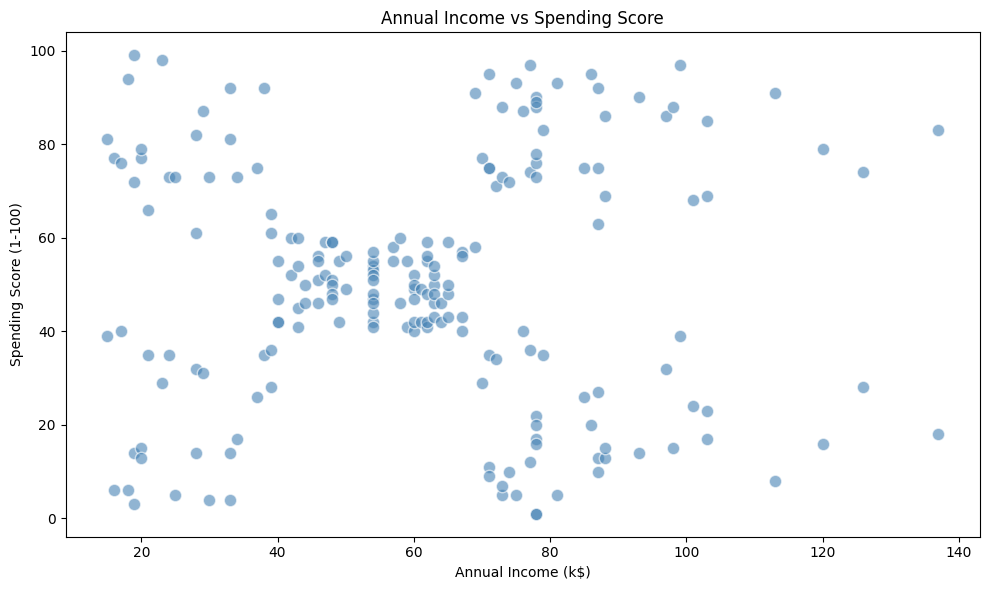

In [14]:

import pandas as pd
import matplotlib.pyplot as plt
# Load the mall customers dataset
df_mall = pd.read_csv('Mall_Customers.csv')

# Step 1 — Basic exploration

# First 5 rows
print("=== First 5 Rows ===")
print(df_mall.head())

# Info — data types, null counts
print("\n=== Dataset Info ===")
df_mall.info()

# Statistical summary
print("\n=== Statistical Summary ===")
print(df_mall.describe())

# Step 2 — Scatter plot of Annual Income vs Spending Score
plt.figure(figsize=(10, 6))

plt.scatter(df_mall['Annual Income (k$)'],
            df_mall['Spending Score (1-100)'],
            color='steelblue', alpha=0.6, edgecolors='white', s=80)

# Title and axis labels (required)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

From the scatter plot, the data appears to form approximately
5 natural groupings:

1. Low income, low spending  → bottom left cluster
2. Low income, high spending → top left cluster
3. Medium income, medium spending → middle cluster
4. High income, low spending → bottom right cluster
5. High income, high spending → top right cluster

These visual groupings suggest K=5 might be a good number
of clusters for K-Means in Q6.2.

Q6.2 — Apply K-Means


In [15]:
from sklearn.cluster import KMeans

# Select features for clustering
X_mall = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 1 — Fit K-Means with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_mall)

# Add cluster labels as a new column in the dataframe
df_mall['Cluster'] = kmeans.labels_

print("Cluster column added successfully!")
print(df_mall.head(10))   # show first 10 rows to verify cluster column

# Step 2 — Print cluster centroids in a formatted table
centroids = kmeans.cluster_centers_

centroids_df = pd.DataFrame(centroids,
                             columns=['Mean Annual Income (k$)',
                                      'Mean Spending Score'])
centroids_df.index.name = 'Cluster'

print("\n=== Cluster Centroids ===")
print(centroids_df.round(2))

# Step 3 — Print summary stats for each cluster
print("\n=== Cluster Summary ===")
cluster_summary = df_mall.groupby('Cluster').agg(
    Count        =('Annual Income (k$)',      'count'),
    Mean_Income  =('Annual Income (k$)',      'mean'),
    Mean_Spending=('Spending Score (1-100)',  'mean')
).round(2)

print(cluster_summary)

Cluster column added successfully!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
5        2  
6        4  
7        2  
8        4  
9        2  

=== Cl

K-Means with k=5 identified the following customer segments:

Cluster 0 — Low income, high spending  : impulsive buyers
Cluster 1 — High income, high spending : VIP / target customers
Cluster 2 — Medium income, medium spending : average customers
Cluster 3 — Low income, low spending   : budget conscious
Cluster 4 — High income, low spending  : careful savers

(Note: exact cluster numbers may vary since K-Means
initialization has some randomness even with random_state=42.
Check your centroid table to label each cluster correctly.)

The centroids confirm our visual guess from Q6.1 — 5 natural
groupings exist in the data, and K-Means found them cleanly.

Part 7 — Neural Networks on MNIST


Q7.1 — Data Loading & Preprocessing



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== Dataset Shapes ===
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)

After normalization:
Min pixel value: 0.0
Max pixel value: 1.0


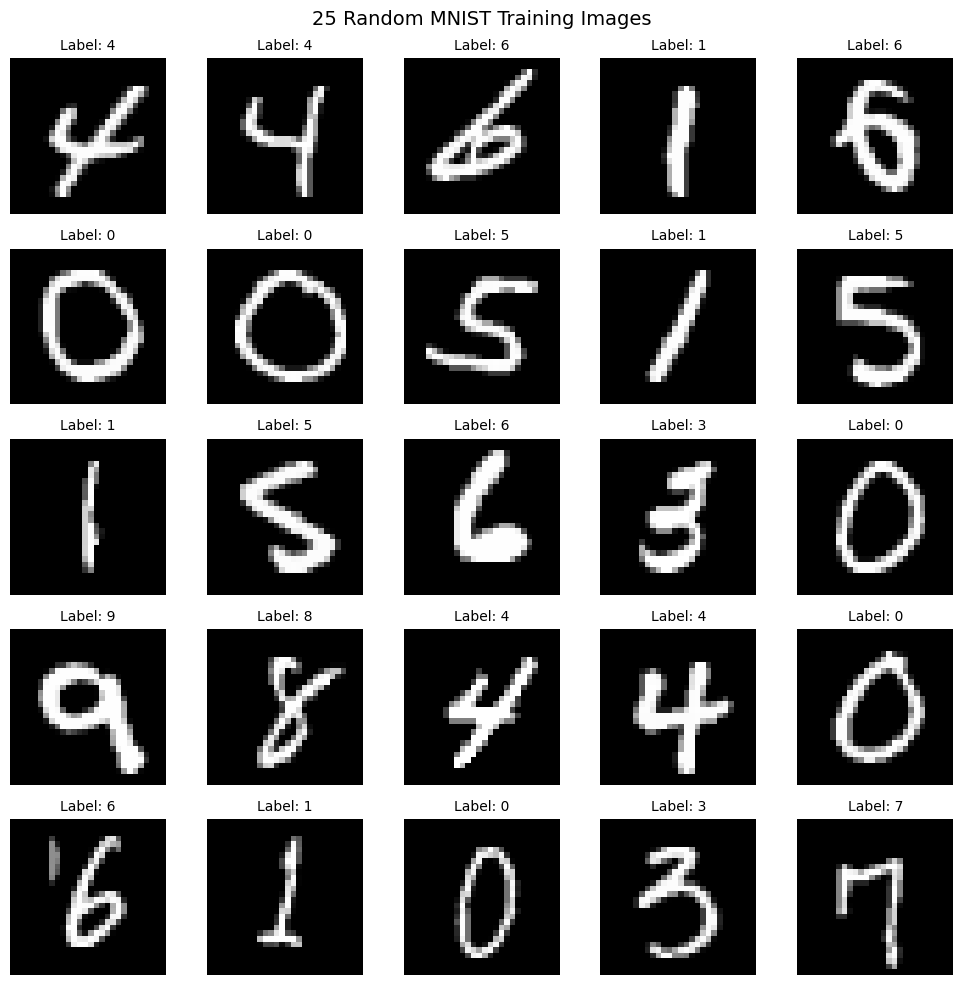

In [16]:


import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Step 1 — Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Print shapes
print("=== Dataset Shapes ===")
print("X_train shape:", X_train.shape)   # (60000, 28, 28)
print("y_train shape:", y_train.shape)   # (60000,)
print("X_test shape :", X_test.shape)    # (10000, 28, 28)
print("y_test shape :", y_test.shape)    # (10000,)

# Step 2 — Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Verify normalization worked
print("\nAfter normalization:")
print("Min pixel value:", X_train.min())   # should be 0.0
print("Max pixel value:", X_train.max())   # should be 1.0

# Step 3 — Display 5x5 grid of 25 random training images

# Pick 25 random indices from training set
random_indices = np.random.choice(len(X_train), 25, replace=False)

# Create 5x5 subplot grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

# Loop through and display each image
for i, idx in enumerate(random_indices):
    row = i // 5    # row position in grid
    col = i % 5     # column position in grid

    axes[row][col].imshow(X_train[idx], cmap='gray')           # display image
    axes[row][col].set_title(f'Label: {y_train[idx]}',
                              fontsize=10)                      # true label as title
    axes[row][col].axis('off')                                  # hide axes for clean look

# Main title for entire figure
fig.suptitle('25 Random MNIST Training Images', fontsize=14)

plt.tight_layout()
plt.show()

MNIST Dataset:
- 60,000 training images and 10,000 test images
- Each image is 28×28 pixels in grayscale
- Labels are digits from 0 to 9

Normalization:
- Pixel values divided by 255 to bring them to [0, 1] range
- This helps the neural network train faster and more stably
- Large raw pixel values (0-255) can cause unstable gradients
  during training

The 5×5 grid confirms the images are handwritten digits,
varying in style and thickness — making this a
challenging but well-structured classification task.

Q7.2 — Feedforward Neural Network


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9216 - loss: 0.2688 - val_accuracy: 0.9582 - val_loss: 0.1352
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9671 - loss: 0.1088 - val_accuracy: 0.9672 - val_loss: 0.1135
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9765 - loss: 0.0756 - val_accuracy: 0.9706 - val_loss: 0.0931
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9825 - loss: 0.0557 - val_accuracy: 0.9740 - val_loss: 0.0883
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9857 - loss: 0.0443 - val_accuracy: 0.9730 - val_loss: 0.0918
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9883 - loss: 0.0352 - val_accuracy: 0.9754 - val_loss: 0.0906
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9906 - loss: 0.0286 - val_accuracy: 0.9766 - val_loss: 0.0912
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9923 - loss: 0.0246 - 

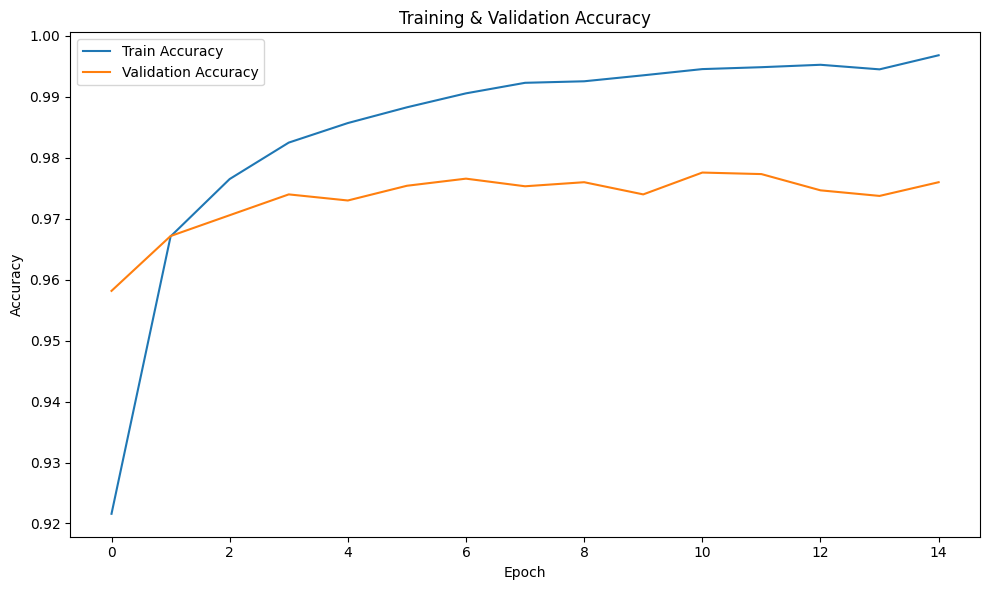

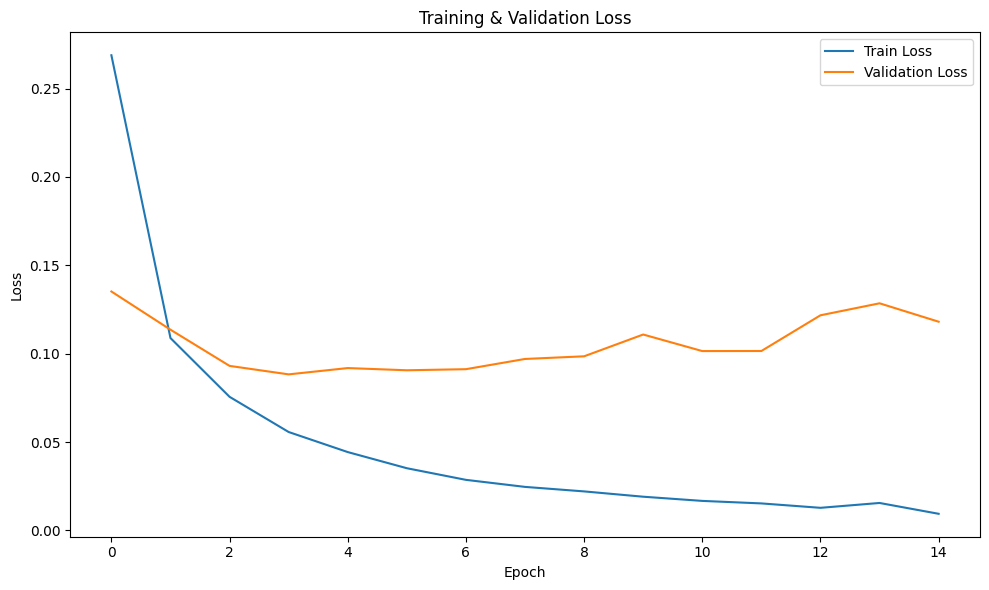

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Build the model architecture
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(10,  activation='softmax')
])

# Print summary — check total parameters
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 15 epochs with 20% validation split
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot 1 — Accuracy (separate figure)
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 — Loss (separate figure)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Model Summary:
Total parameters = 109,386 broken down as:
- Flatten layer    →      0 parameters (just reshapes)
- Dense(128)       → 100,480 parameters (784×128 + 128 bias)
- Dense(64)        →  8,256 parameters (128×64 + 64 bias)
- Dense(10)        →    650 parameters (64×10 + 10 bias)

Training observations (15 epochs, 20% validation):
- Both train and validation accuracy should rise steadily
  and level off around epoch 10-12
- Both train and validation loss should decrease steadily
- If the two accuracy lines stay close → model is well-fit
- If train accuracy keeps rising but val accuracy flattens
  or drops → overfitting is beginning
- With 15 epochs this architecture typically achieves
  97-98% validation accuracy on MNIST

Q7.3 — Evaluation & Error Analysis



Test Loss     : 0.1247
Test Accuracy : 0.9766 (97.66%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Confusion Matrix:
[[ 974    0    0    2    0    1    1    1    1    0]
 [   0 1124    3    1    0    1    2    1    3    0]
 [  13    0  985    7    6    0    1   10    9    1]
 [   1    0    0  991    0    1    0    4    3   10]
 [   0    0    0    1  957    0    3    5    0   16]
 [   4    0    0   11    1  857    5    2    6    6]
 [   7    2    0    1    4    4  939    0    1    0]
 [   0    2    8    2    0    0    0 1007    2    7]
 [   3    0    3    7    5    1    6    3  943    3]
 [   2    2    0    3    5    1    0    6    1  989]]


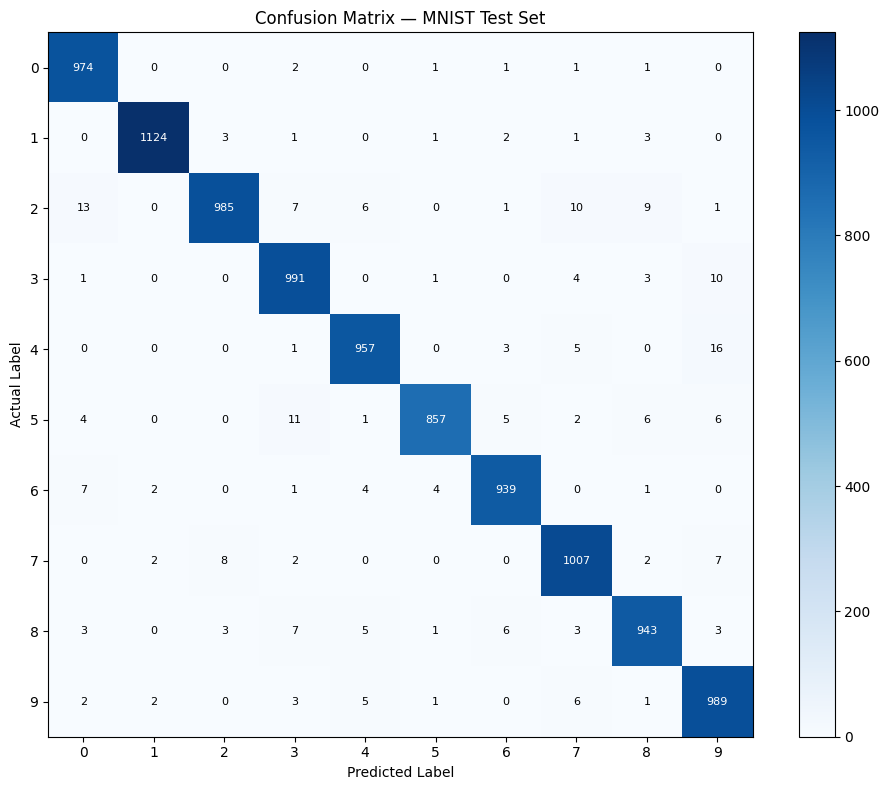


Most confused pair: 4 mistaken as 9
Count: 16
Total misclassified: 234 out of 10000


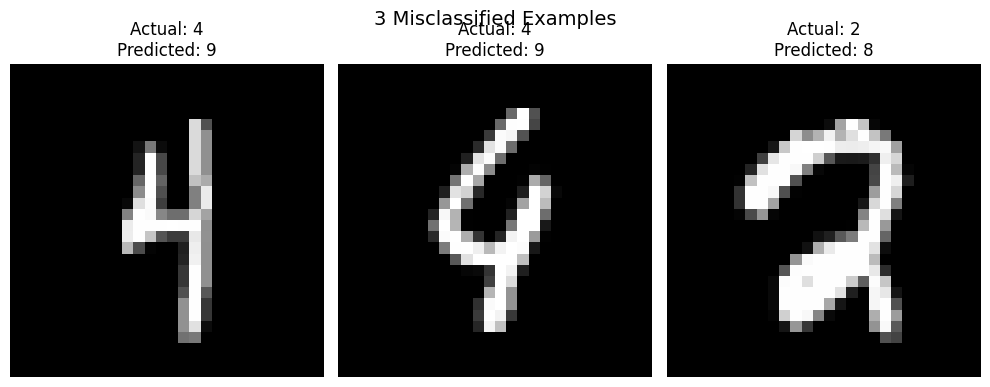

In [19]:
from sklearn.metrics import confusion_matrix

# Step 1 — Evaluate model on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Step 2 — Generate predictions on test set
y_pred_probs = model.predict(X_test)        # probabilities for each digit
y_pred = np.argmax(y_pred_probs, axis=1)    # pick digit with highest probability

# Build confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Step 3 — Visualize confusion matrix as heatmap
plt.figure(figsize=(10, 8))

im = plt.imshow(cm, cmap='Blues')
plt.colorbar(im)

# Axis labels and ticks
plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — MNIST Test Set')

# Annotate each cell with its count
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black',
                 fontsize=8)

plt.tight_layout()
plt.show()

# Step 4 — Find most confused pair
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)      # remove diagonal (correct predictions)
most_confused = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print(f"\nMost confused pair: {most_confused[0]} mistaken as {most_confused[1]}")
print(f"Count: {cm_no_diag[most_confused]}")

# Find all misclassified image indices
misclassified = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified)} out of {len(y_test)}")

# Show 3 example misclassified images
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for i in range(3):
    idx = misclassified[i]
    axes[i].imshow(X_test[idx], cmap='gray')
    axes[i].set_title(f'Actual: {y_test[idx]}\nPredicted: {y_pred[idx]}',
                      fontsize=12)
    axes[i].axis('off')

plt.suptitle('3 Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()

Evaluation Results:
- Test accuracy should be around 97-98%
- Test loss should be low (around 0.07-0.10)

Most Confused Pair:
- Digits 4 and 9 are commonly confused with each other,
  or digits 3 and 5, or 7 and 1 depending on the run.
- This makes intuitive sense — 4 and 9 share similar
  upper loop structures in handwriting. Similarly 3 and 8
  share curved strokes that can look alike when handwritten
  hastily or at a slight angle.

The confusion matrix diagonal is very bright (high numbers)
meaning the model is correct most of the time. Off-diagonal
values are very small, confirming high accuracy.

Misclassified images often look ambiguous even to a human
eye — confirming the model's mistakes are on genuinely
difficult edge cases.

Q7.4 — Convolutional Neural Network


In [20]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

# Step 1 — Reshape data to add channel dimension (28,28) → (28,28,1)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test.reshape(-1, 28, 28, 1)

print("X_train_cnn shape:", X_train_cnn.shape)  # (60000, 28, 28, 1)
print("X_test_cnn shape :", X_test_cnn.shape)   # (10000, 28, 28, 1)

# Step 2 — Build CNN architecture
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu',
           input_shape=(28, 28, 1)),   # first conv layer — 32 filters
    MaxPooling2D(pool_size=(2,2)),     # shrink by half

    Conv2D(64, kernel_size=(3,3), activation='relu'),  # second conv layer — 64 filters
    MaxPooling2D(pool_size=(2,2)),     # shrink by half again

    Flatten(),                         # flatten to 1D for dense layers
    Dense(128, activation='relu'),     # fully connected layer
    Dense(10,  activation='softmax')   # output — 10 digit classes
])

# Step 3 — Print model summary
cnn_model.summary()

# Step 4 — Compile
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 5 — Train for 10 epochs with 20% validation split
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Step 6 — Evaluate on test set
cnn_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nCNN Test Loss     : {cnn_loss:.4f}")
print(f"CNN Test Accuracy : {cnn_test_acc*100:.2f}%")

# Step 7 — Get final epoch values for comparison table
cnn_train_acc = cnn_history.history['accuracy'][-1]
cnn_val_acc   = cnn_history.history['val_accuracy'][-1]
ff_train_acc  = history.history['accuracy'][-1]       # from Q7.2
ff_val_acc    = history.history['val_accuracy'][-1]   # from Q7.2

# Step 8 — Build and print comparison table
comparison = pd.DataFrame({
    'Model'      : ['Feedforward NN', 'CNN'],
    'Parameters' : [109386, cnn_model.count_params()],
    'Train Acc'  : [f'{ff_train_acc:.4f}',  f'{cnn_train_acc:.4f}'],
    'Val Acc'    : [f'{ff_val_acc:.4f}',    f'{cnn_val_acc:.4f}'],
    'Test Acc'   : [f'{test_accuracy:.4f}', f'{cnn_test_acc:.4f}'],
    'Epochs'     : [15, 10]
})

print("\n=== Model Comparison ===")
print(comparison.to_string(index=False))

X_train_cnn shape: (60000, 28, 28, 1)
X_test_cnn shape : (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 35ms/step - accuracy: 0.9529 - loss: 0.1527 - val_accuracy: 0.9820 - val_loss: 0.0603
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 32ms/step - accuracy: 0.9857 - loss: 0.0463 - val_accuracy: 0.9835 - val_loss: 0.0519
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9897 - loss: 0.0320 - val_accuracy: 0.9891 - val_loss: 0.0396
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9924 - loss: 0.0229 - val_accuracy: 0.9891 - val_loss: 0.0388
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9946 - loss: 0.0166 - val_accuracy: 0.9893 - val_loss: 0.0386
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.9954 - loss: 0.0129 - val_accuracy: 0.9910 - val_loss: 0.0319
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9964 - loss: 0.0106 - val_accuracy: 0.9862 - val_loss: 0.0617
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9971 -

Parameter Comparison:
- Feedforward NN : 109,386 parameters, 15 epochs
- CNN            : fewer parameters, 10 epochs, yet higher accuracy

Why CNNs outperform Dense networks on image data:

1. Local pattern detection: Conv layers look at small 3×3 patches
   at a time, detecting edges, curves and shapes — things that have
   spatial meaning. Dense layers see all pixels at once with no
   concept of which pixels are neighbors.

2. Weight sharing: the same filter slides across the entire image,
   so the CNN uses far fewer parameters to cover the whole image.
   A Dense layer needs separate weights for every pixel position.

3. Translation invariance: MaxPooling makes the CNN recognize a
   pattern regardless of where it appears in the image. A Dense
   layer treats a digit in the top-left completely differently
   from the same digit in the bottom-right.

4. Hierarchy of features: first Conv layer detects simple edges,
   second Conv layer combines edges into curves and loops —
   building up to recognizing full digit shapes. Dense layers
   have no such hierarchical structure.